In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
import numpy as np

In [4]:
orig = pd.read_csv("original_hula_results.csv")

In [5]:
mod = pd.read_csv("modified_hula_results.csv")

In [6]:
print("Original shape:", orig.shape)

Original shape: (1000, 5)


In [7]:
print("Modified shape:", mod.shape)

Modified shape: (1000, 5)


In [8]:
orig.head()

,load_percent,time_sec,probes_per_sec,total_probes,overhead
0,10,0,5.254,5.25,0.000027
1,10,1,5.005,10.26,0.000026
2,10,2,4.882,15.14,0.000025
3,10,3,5.000,20.14,0.000026
4,10,4,5.153,25.29,0.000026


In [9]:
orig_10 = orig[orig["load_percent"] == 10]
mod_10 = mod[mod["load_percent"] == 10]

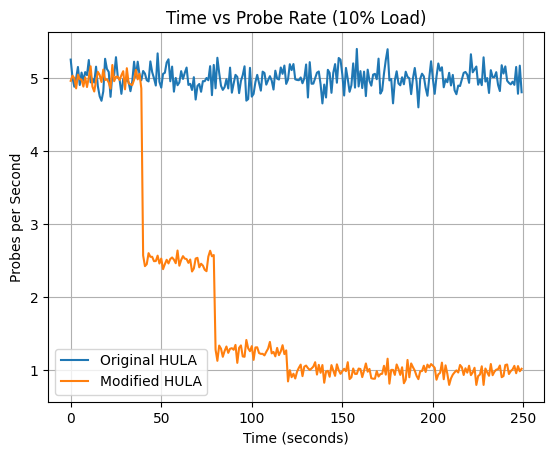

In [10]:
plt.figure()
plt.plot(orig_10["time_sec"], orig_10["probes_per_sec"], label="Original HULA")
plt.plot(mod_10["time_sec"], mod_10["probes_per_sec"], label="Modified HULA")

plt.xlabel("Time (seconds)")
plt.ylabel("Probes per Second")
plt.title("Time vs Probe Rate (10% Load)")
plt.legend()
plt.grid(True)

plt.show()

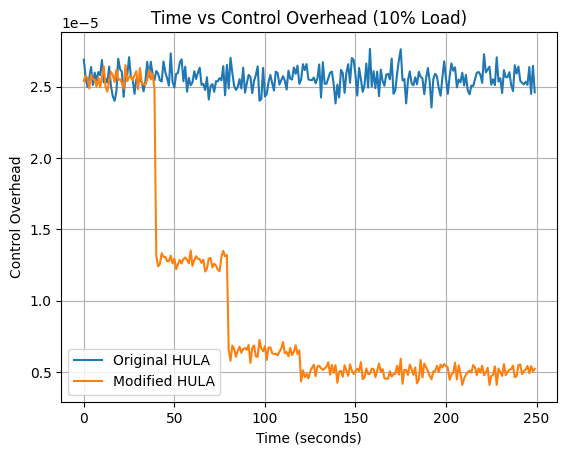

In [11]:
plt.figure()
plt.plot(orig_10["time_sec"], orig_10["overhead"], label="Original HULA")
plt.plot(mod_10["time_sec"], mod_10["overhead"], label="Modified HULA")

plt.xlabel("Time (seconds)")
plt.ylabel("Control Overhead")
plt.title("Time vs Control Overhead (10% Load)")
plt.legend()
plt.grid(True)

plt.show()

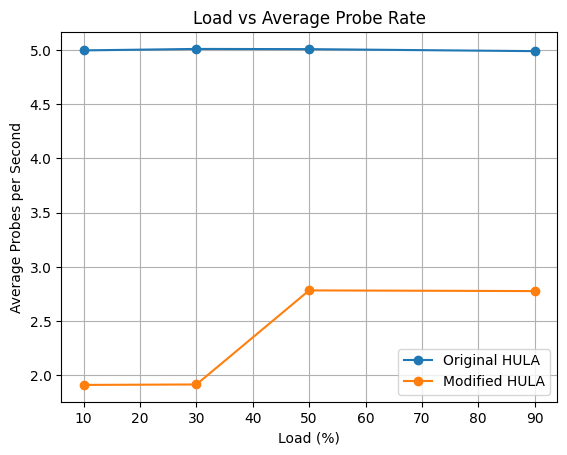

In [12]:
orig_avg = orig.groupby("load_percent")["probes_per_sec"].mean()
mod_avg = mod.groupby("load_percent")["probes_per_sec"].mean()

plt.figure()
plt.plot(orig_avg.index, orig_avg.values, marker='o', label="Original HULA")
plt.plot(mod_avg.index, mod_avg.values, marker='o', label="Modified HULA")

plt.xlabel("Load (%)")
plt.ylabel("Average Probes per Second")
plt.title("Load vs Average Probe Rate")
plt.legend()
plt.grid(True)

plt.show()

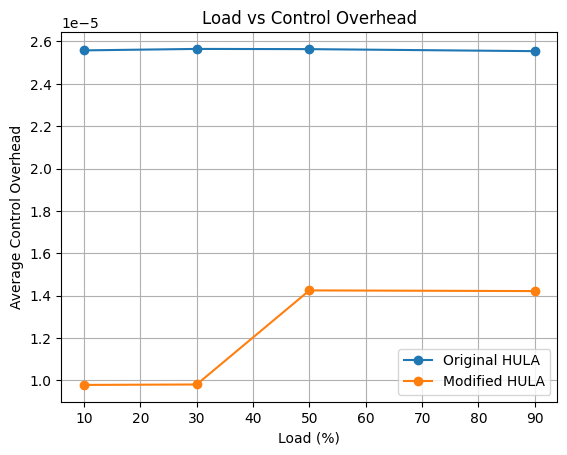

In [13]:
orig_over = orig.groupby("load_percent")["overhead"].mean()
mod_over = mod.groupby("load_percent")["overhead"].mean()

plt.figure()
plt.plot(orig_over.index, orig_over.values, marker='o', label="Original HULA")
plt.plot(mod_over.index, mod_over.values, marker='o', label="Modified HULA")

plt.xlabel("Load (%)")
plt.ylabel("Average Control Overhead")
plt.title("Load vs Control Overhead")
plt.legend()
plt.grid(True)

plt.show()

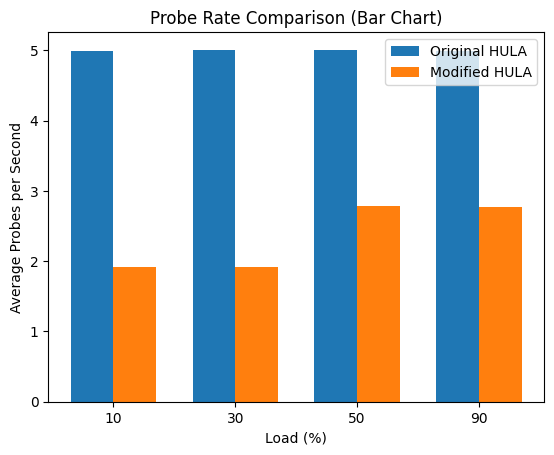

In [14]:
loads = orig_avg.index

x = np.arange(len(loads))
width = 0.35

plt.figure()
plt.bar(x - width/2, orig_avg.values, width, label="Original HULA")
plt.bar(x + width/2, mod_avg.values, width, label="Modified HULA")

plt.xlabel("Load (%)")
plt.ylabel("Average Probes per Second")
plt.title("Probe Rate Comparison (Bar Chart)")
plt.xticks(x, loads)
plt.legend()

plt.show()

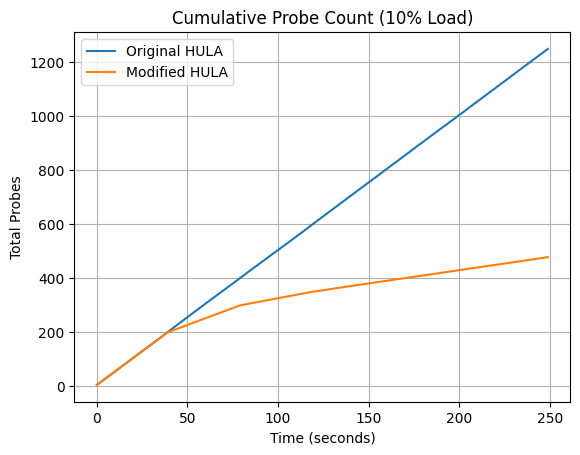

In [15]:
plt.figure()
plt.plot(orig_10["time_sec"], orig_10["total_probes"], label="Original HULA")
plt.plot(mod_10["time_sec"], mod_10["total_probes"], label="Modified HULA")

plt.xlabel("Time (seconds)")
plt.ylabel("Total Probes")
plt.title("Cumulative Probe Count (10% Load)")
plt.legend()
plt.grid(True)

plt.show()

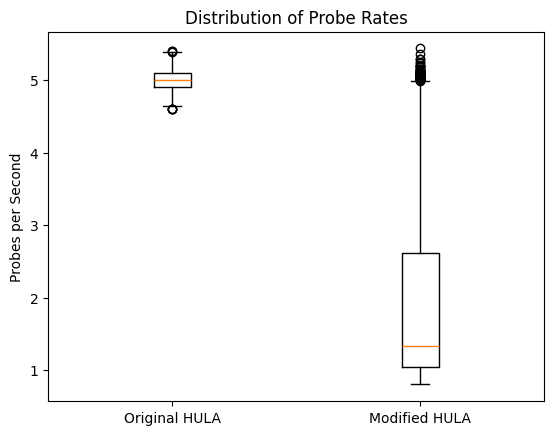

In [16]:
plt.figure()
plt.boxplot([
    orig["probes_per_sec"],
    mod["probes_per_sec"]
])

plt.xticks([1, 2], ["Original HULA", "Modified HULA"])
plt.ylabel("Probes per Second")
plt.title("Distribution of Probe Rates")

plt.show()

In [17]:
time = np.arange(0, 120)

In [18]:
mod_probe = []
current_rate = 5

for t in time:
    
    # Congestion spike between 40s and 70s
    if 40 <= t <= 70:
        current_rate = 5   # reset to high rate during congestion
    
    else:
        # Exponential backoff during stability
        if t % 10 == 0 and current_rate > 1:
            current_rate = current_rate / 2
        
        # Minimum probe rate = 1
        if current_rate < 1:
            current_rate = 1
    
    mod_probe.append(current_rate)

In [19]:
orig_probe = np.ones_like(time) * 5 

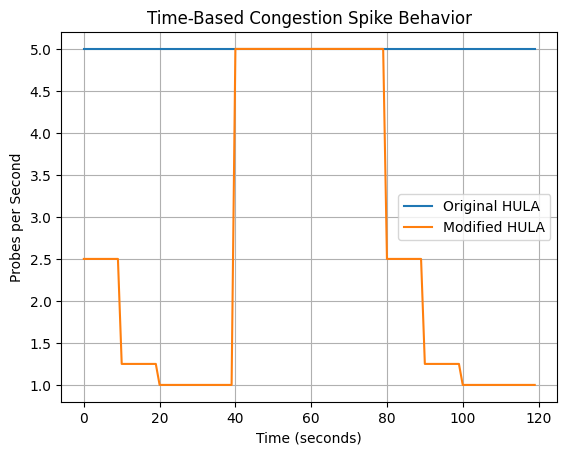

In [20]:
plt.figure()

plt.plot(time, orig_probe, label="Original HULA")
plt.plot(time, mod_probe, label="Modified HULA")

plt.xlabel("Time (seconds)")
plt.ylabel("Probes per Second")
plt.title("Time-Based Congestion Spike Behavior")
 
plt.legend()
plt.grid(True)

plt.show()